# Agua CDMX PCA

Este notebook construye una base analitica a nivel colonia a partir del archivo `consumo_agua_historico_2019.csv` y de informacion complementaria de hogares.

Primero se limpian y transforman los datos, despues se genera una tabla resumen por colonia, se incorporan variables socioeconomicas y se aplica PCA para explorar patrones de consumo y composicion social.

Finalmente, se revisan outliers, se crea una version limpia de la tabla y se prueban modelos predictivos para estimar `consumo_total` con base en las variables disponibles.


In [1]:
# Instalamos scikit-learn dentro del entorno del notebook.
# Esta libreria se usa despues para PCA y para los modelos predictivos.
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cargamos las librerias principales para manipulacion de datos,
# visualizacion y modelado estadistico.
# Tambien importamos funciones auxiliares del proyecto para enriquecer
# la tabla final con informacion socioeconomica y de hogares.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

from build_tabla_colonia_consumo import MANUAL_CVE_MAP, load_hogares, normalize_text

# Ajustamos opciones de visualizacion para mostrar mas columnas y
# formatear numeros con separador de miles y dos decimales.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [3]:
# Definimos las rutas base del archivo de consumo, del CSV de salida
# y de la carpeta donde se guardaran las graficas del PCA.
base_path = Path('.')
agua_path = base_path / 'consumo_agua' / 'consumo_agua_historico_2019.csv'
output_path = base_path / 'consumo_agua' / 'tabla_colonia_consumo.csv'
graficas_path = base_path / 'graficas_pca'
graficas_path.mkdir(parents=True, exist_ok=True)

# Funcion auxiliar para exportar cada figura con un nombre consistente.
def guardar_grafica(nombre_archivo):
    ruta = graficas_path / nombre_archivo
    plt.savefig(ruta, dpi=300, bbox_inches='tight')
    return ruta

agua_path


PosixPath('consumo_agua/consumo_agua_historico_2019.csv')

## 1. Carga inicial


In [4]:
# Leemos el archivo historico de consumo de agua desde la ruta definida antes.
df = pd.read_csv(agua_path)

# Convertimos la fecha de referencia a formato datetime para poder
# trabajarla despues como variable temporal si hace falta.
df['fecha_referencia'] = pd.to_datetime(df['fecha_referencia'])

# Revisamos el tamano inicial de la base para saber con cuantas filas
# y columnas arranca el procesamiento.
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]:,}')

# Mostramos las primeras filas para inspeccionar la estructura general.
df.head()


Filas: 71,102
Columnas: 16


,fecha_referencia,anio,bimestre,consumo_total_mixto,consumo_prom_dom,consumo_total_dom,consumo_prom_mixto,consumo_total,consumo_prom,consumo_prom_no_dom,consumo_total_no_dom,indice_des,colonia,alcaldia,latitud,longitud
0,2019-06-30,2019,3,159.72,42.57,468.23,53.24,631.00,42.07,3.05,3.05,ALTO,7 DE NOVIEMBRE,GUSTAVO A. MADERO,19.46,-99.11
1,2019-06-30,2019,3,0.00,35.94,107.81,0.00,115.13,28.78,7.32,7.32,MEDIO,7 DE NOVIEMBRE,GUSTAVO A. MADERO,19.46,-99.11
2,2019-06-30,2019,3,0.00,24.59,122.93,0.00,197.96,32.99,75.03,75.03,POPULAR,7 DE NOVIEMBRE,GUSTAVO A. MADERO,19.46,-99.11
3,2019-06-30,2019,3,0.00,0.00,0.00,0.00,253.53,84.51,84.51,253.53,BAJO,GERTRUDIS SANCHEZ 3A SECCION,GUSTAVO A. MADERO,19.46,-99.10
4,2019-06-30,2019,3,56.72,67.44,539.49,56.72,839.35,76.30,121.57,243.14,BAJO,PRO HOGAR I,AZCAPOTZALCO,19.47,-99.15


## 2. Eliminacion de filas repetidas

Antes de agregar o transformar, quitamos filas exactamente repetidas.


In [5]:
# Eliminamos filas exactamente duplicadas para evitar contar dos veces
# el mismo registro en los pasos de agregacion posteriores.
df_limpio = df.drop_duplicates().copy()

# Comparamos el tamano antes y despues de la limpieza para verificar
# cuantas observaciones repetidas fueron removidas.
print(f'Filas antes: {len(df):,}')
print(f'Filas despues: {len(df_limpio):,}')
print(f'Filas eliminadas: {len(df) - len(df_limpio):,}')


Filas antes: 71,102
Filas despues: 69,652
Filas eliminadas: 1,450


## 3. Eliminacion de variables no prioritarias

Por ahora conservamos solo las variables necesarias para trabajar con `consumo_total` y con la composicion por `indice_des`.


In [6]:
# Definimos las variables que no vamos a usar en esta version del analisis.
# Se excluyen consumos desagregados o promedios redundantes, asi como
# coordenadas geograficas que por ahora no entran al modelo.
columnas_a_eliminar = [
    'consumo_total_mixto',
    'consumo_prom_dom',
    'consumo_total_dom',
    'consumo_prom_mixto',
    'consumo_prom',
    'consumo_prom_no_dom',
    'consumo_total_no_dom',
    'latitud',
    'longitud'
]

# Construimos una tabla mas enfocada, conservando solo las columnas
# necesarias para resumir consumo_total y la composicion por indice_des.
df_total = df_limpio.drop(columns=columnas_a_eliminar).copy()

# Revisamos las primeras filas de la version reducida de la base.
df_total.head()


,fecha_referencia,anio,bimestre,consumo_total,indice_des,colonia,alcaldia
0,2019-06-30,2019,3,631.00,ALTO,7 DE NOVIEMBRE,GUSTAVO A. MADERO
1,2019-06-30,2019,3,115.13,MEDIO,7 DE NOVIEMBRE,GUSTAVO A. MADERO
2,2019-06-30,2019,3,197.96,POPULAR,7 DE NOVIEMBRE,GUSTAVO A. MADERO
3,2019-06-30,2019,3,253.53,BAJO,GERTRUDIS SANCHEZ 3A SECCION,GUSTAVO A. MADERO
4,2019-06-30,2019,3,839.35,BAJO,PRO HOGAR I,AZCAPOTZALCO


## 4. Codificacion ordinal de indice_des

Tratamos `indice_des` como una variable ordinal para conservar su orden en una forma numerica.


In [7]:
# Definimos una codificacion ordinal para `indice_des`.
# Esto preserva el orden de los niveles socioeconomicos en una escala numerica.
mapa_indice_des = {
    'POPULAR': 1,
    'BAJO': 2,
    'MEDIO': 3,
    'ALTO': 4
}

# Aplicamos el mapeo para crear una nueva columna numerica que luego
# puede usarse en calculos agregados o indicadores compuestos.
df_total['indice_des_num'] = df_total['indice_des'].map(mapa_indice_des)

# Verificamos la correspondencia final entre etiqueta original y codigo numerico.
df_total[['indice_des', 'indice_des_num']].drop_duplicates().sort_values('indice_des_num')


,indice_des,indice_des_num
2,POPULAR,1
3,BAJO,2
1,MEDIO,3
0,ALTO,4


## 5. Colapso de bimestre

Si una misma combinacion de `alcaldia + colonia + indice_des` aparece en varios bimestres, sumamos `consumo_total` para dejar una sola fila por combinacion.


In [8]:
df_colapsado = (
    df_total.groupby(['alcaldia', 'colonia', 'indice_des', 'indice_des_num'], as_index=False)
    .agg(consumo_total=('consumo_total', 'sum'))
)

df_colapsado.head()


,alcaldia,colonia,indice_des,indice_des_num,consumo_total
0,ALVARO OBREGON,19 DE MAYO,POPULAR,1,"15,121.25"
1,ALVARO OBREGON,1RA VICTORIA,BAJO,2,"12,978.45"
2,ALVARO OBREGON,1RA VICTORIA SECCION BOSQUES,BAJO,2,"4,057.66"
3,ALVARO OBREGON,1RA VICTORIA SECCION BOSQUES,POPULAR,1,"17,523.02"
4,ALVARO OBREGON,2DA JALALPA TEPITO (AMPL),BAJO,2,"14,705.88"


## 6. Tabla final por colonia


En esta sección se transforma la base a una escala analítica más agregada, construyendo una sola observación por combinación de alcaldia y colonia. Para lograrlo, el consumo se reorganiza según los distintos niveles de indice_des, de modo que cada colonia quede descrita por la distribución de su consumo entre categorías socioeconómicas.

A partir de esa reorganización, se calculan proporciones de consumo por nivel socioeconómico respecto al consumo_total de cada colonia. Después, estas proporciones se sintetizan mediante las funciones de socioeconomic features, que comprimen la información original en indicadores más compactos e interpretables. En particular, se genera un nivel_promedio_ponderado, que resume la composición socioeconómica dominante, y un índice de diversidad_shannon, que mide qué tan heterogénea es esa composición dentro de cada colonia.

Finalmente, esta tabla enriquecida se complementa con el total de hogares por colonia, para obtener una base final más condensada y adecuada para el análisis exploratorio, el PCA y los modelos posteriores.

Nota: se utiliza la combinación alcaldia + colonia como llave de identificación, ya que existen nombres de colonia repetidos en distintas alcaldías.

In [9]:
# Definimos localmente la logica para sintetizar la composicion
# socioeconomica de cada colonia a partir de las proporciones de consumo.
def add_socioeconomic_features(
    df,
    popular_col='popular',
    bajo_col='bajo',
    medio_col='medio',
    alto_col='alto',
    normalize_if_needed=True,
):
    cols = [popular_col, bajo_col, medio_col, alto_col]
    result = df.copy()

    proportions = result[cols].astype(float)
    row_sums = proportions.sum(axis=1)

    # Si las columnas vienen en escala 0-100, las convertimos a proporciones.
    if normalize_if_needed:
        proportions = proportions.div(
            np.where(row_sums > 1.5, row_sums, 1),
            axis=0,
        )

    # Calculamos un nivel socioeconomico promedio ponderado en escala 1 a 4.
    weights = np.array([1.0, 2.0, 3.0, 4.0])
    result['nivel_promedio_ponderado'] = proportions.mul(weights, axis=1).sum(axis=1)

    # Calculamos el indice de Shannon para medir la diversidad interna.
    safe_proportions = proportions.where(proportions > 0, 1.0)
    result['diversidad_shannon'] = -(proportions * np.log(safe_proportions)).sum(axis=1)

    return result

tabla_colonia = (
    df_colapsado.pivot_table(
        index=['alcaldia', 'colonia'],
        columns='indice_des',
        values='consumo_total',
        aggfunc='sum',
        fill_value=0
    )
    .rename(columns={
        'POPULAR': 'consumo_popular',
        'BAJO': 'consumo_bajo',
        'MEDIO': 'consumo_medio',
        'ALTO': 'consumo_alto'
    })
    .reset_index()
)

for col in ['consumo_popular', 'consumo_bajo', 'consumo_medio', 'consumo_alto']:
    if col not in tabla_colonia.columns:
        tabla_colonia[col] = 0

tabla_colonia['consumo_total'] = (
    tabla_colonia['consumo_popular']
    + tabla_colonia['consumo_bajo']
    + tabla_colonia['consumo_medio']
    + tabla_colonia['consumo_alto']
)

tabla_colonia['perc_popular'] = np.where(tabla_colonia['consumo_total'] > 0, tabla_colonia['consumo_popular'] / tabla_colonia['consumo_total'], 0)
tabla_colonia['perc_bajo'] = np.where(tabla_colonia['consumo_total'] > 0, tabla_colonia['consumo_bajo'] / tabla_colonia['consumo_total'], 0)
tabla_colonia['perc_medio'] = np.where(tabla_colonia['consumo_total'] > 0, tabla_colonia['consumo_medio'] / tabla_colonia['consumo_total'], 0)
tabla_colonia['perc_alto'] = np.where(tabla_colonia['consumo_total'] > 0, tabla_colonia['consumo_alto'] / tabla_colonia['consumo_total'], 0)

tabla_colonia = add_socioeconomic_features(
    tabla_colonia,
    popular_col='perc_popular',
    bajo_col='perc_bajo',
    medio_col='perc_medio',
    alto_col='perc_alto'
)

# Reutilizamos la logica de cruce ya trabajada en `build_tabla_colonia_consumo.py`
# para traer el total de hogares por colonia. El cruce se hace con nombres
# normalizados de alcaldia y colonia, y despues se corrigen manualmente los
# casos que ya sabiamos que no empatan solo por texto.
tabla_colonia['alcaldia_norm'] = tabla_colonia['alcaldia'].map(normalize_text)
tabla_colonia['colonia_norm'] = tabla_colonia['colonia'].map(normalize_text)

hogares = load_hogares()
tabla_colonia = tabla_colonia.merge(
    hogares[['alcaldia_norm', 'colonia_norm', 'cve_col', 'Sum_TotHog']],
    on=['alcaldia_norm', 'colonia_norm'],
    how='left'
)

if MANUAL_CVE_MAP:
    hogares_by_cve = hogares[['cve_col', 'Sum_TotHog']].drop_duplicates(subset=['cve_col'])
    manual_df = pd.DataFrame([
        {'alcaldia': alcaldia, 'colonia': colonia, 'cve_col': cve_col}
        for (alcaldia, colonia), cve_col in MANUAL_CVE_MAP.items()
    ]).merge(hogares_by_cve, on='cve_col', how='left')

    tabla_colonia = tabla_colonia.merge(
        manual_df.rename(columns={
            'cve_col': 'cve_col_manual',
            'Sum_TotHog': 'Sum_TotHog_manual'
        }),
        on=['alcaldia', 'colonia'],
        how='left'
    )
    tabla_colonia['cve_col'] = tabla_colonia['cve_col'].fillna(tabla_colonia['cve_col_manual'])
    tabla_colonia['Sum_TotHog'] = tabla_colonia['Sum_TotHog'].fillna(tabla_colonia['Sum_TotHog_manual'])
    tabla_colonia = tabla_colonia.drop(columns=['cve_col_manual', 'Sum_TotHog_manual'])

tabla_colonia['tot_hog'] = tabla_colonia['Sum_TotHog'].astype('Int64')

tabla_pca = tabla_colonia.assign(
    colonia_alcaldia=tabla_colonia['colonia'] + ' | ' + tabla_colonia['alcaldia']
)[[
    'colonia_alcaldia',
    'consumo_total',
    'tot_hog',
    'nivel_promedio_ponderado',
    'diversidad_shannon'
]].sort_values('colonia_alcaldia').reset_index(drop=True)

tabla_pca.head()


,colonia_alcaldia,consumo_total,tot_hog,nivel_promedio_ponderado,diversidad_shannon
0,10 DE ABRIL | MIGUEL HIDALGO,"17,694.87",108,3.73,0.63
1,10 DE MAYO | VENUSTIANO CARRANZA,"46,761.97",547,1.90,0.33
2,12 DE DICIEMBRE | IZTAPALAPA,"18,441.64",815,1.68,0.63
3,15 DE AGOSTO | GUSTAVO A. MADERO,"43,261.61",1079,2.23,0.54
4,16 DE SEPTIEMBRE | MIGUEL HIDALGO,"51,640.00",691,2.73,0.80


In [10]:

# Guardamos la tabla final en formato CSV para reutilizarla
# en las siguientes etapas del analisis fuera de este notebook.
tabla_pca.to_csv(output_path, index=False)

# Mostramos la ruta del archivo generado para confirmar
# que la exportacion se realizo correctamente.
print(f'CSV guardado en: {output_path}')

CSV guardado en: consumo_agua/tabla_colonia_consumo.csv


In [11]:

# Generamos un resumen descriptivo de la tabla final para revisar
# el comportamiento general de las variables, sus conteos y distribuciones.
tabla_pca.describe(include='all')


,colonia_alcaldia,consumo_total,tot_hog,nivel_promedio_ponderado,diversidad_shannon
count,1553,"1,553.00","1,551.00","1,553.00","1,553.00"
unique,1553,NaN,<NA>,NaN,NaN
top,10 DE ABRIL | MIGUEL HIDALGO,NaN,<NA>,NaN,NaN
freq,1,NaN,<NA>,NaN,NaN
mean,NaN,"75,099.90","2,006.53",2.00,0.49
std,NaN,"109,888.76","5,927.58",0.86,0.38
min,NaN,0.00,0.00,0.00,-0.00
25%,NaN,"6,681.33",610.50,1.41,0.03
50%,NaN,"36,240.92","1,272.00",1.92,0.54
75%,NaN,"92,310.85","2,471.00",2.42,0.73


## 7. PCA sobre la tabla final

En esta seccion aplicamos PCA (Analisis de Componentes Principales) sobre las variables numericas de `tabla_pca`.

La idea es resumir la variacion conjunta de estas variables en nuevos ejes (`PC1`, `PC2`, etc.) que concentran la mayor parte de la informacion posible.

Variables que entran al PCA:
- `consumo_total`
- `tot_hog`
- `nivel_promedio_ponderado`
- `diversidad_shannon`

Antes de correr PCA, estandarizamos las variables porque cada una vive en una escala distinta. Si no se hace esto, `consumo_total` dominaria el analisis solo por tener magnitudes mas grandes.


In [12]:
# Seleccionamos solo las variables numericas que queremos resumir con PCA.
# `colonia_alcaldia` se conserva como identificador, pero no entra al analisis
# porque PCA solo trabaja con variables numericas.
variables_pca = [
    'consumo_total',
    'tot_hog',
    'nivel_promedio_ponderado',
    'diversidad_shannon'
]

# Quitamos temporalmente filas con valores faltantes en las variables del PCA.
# Esto evita errores al ajustar el modelo y deja claro sobre que colonias
# se pudieron calcular las componentes principales.
tabla_pca_modelo = tabla_pca.dropna(subset=variables_pca).copy()

X = tabla_pca_modelo[variables_pca].copy()

# Estandarizacion (z-score):
# - centra cada variable en media 0
# - la deja con desviacion estandar 1
# Esto hace comparables las cuatro columnas antes del PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ajustamos PCA con tantas componentes como variables originales.
# Aqui eso significa 4 componentes maximas.
pca = PCA(n_components=len(variables_pca), random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Construimos una tabla con los scores del PCA.
# Cada PC es una combinacion lineal de las variables originales.
component_names = [f'PC{i + 1}' for i in range(X_pca.shape[1])]
tabla_pca_scores = pd.DataFrame(X_pca, columns=component_names, index=tabla_pca_modelo.index)
tabla_pca_scores = pd.concat([
    tabla_pca_modelo[['colonia_alcaldia']].reset_index(drop=True),
    tabla_pca_scores.reset_index(drop=True)
], axis=1)

tabla_pca_scores.head()


/Users/isalgadog/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/isalgadog/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/isalgadog/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


,colonia_alcaldia,PC1,PC2,PC3,PC4
0,10 DE ABRIL | MIGUEL HIDALGO,0.88,-1.29,-0.29,-1.43
1,10 DE MAYO | VENUSTIANO CARRANZA,-0.50,-0.13,-0.20,-0.02
2,12 DE DICIEMBRE | IZTAPALAPA,-0.39,-0.15,0.64,-0.02
3,15 DE AGOSTO | GUSTAVO A. MADERO,0.00,-0.32,0.12,-0.29
4,16 DE SEPTIEMBRE | MIGUEL HIDALGO,0.68,-0.73,0.41,-0.53


In [13]:
# Varianza explicada:
# Este resultado nos dice que porcentaje de la informacion total captura
# cada componente principal.
varianza_explicada = pd.DataFrame({
    'componente': component_names,
    'varianza_explicada': pca.explained_variance_ratio_,
    'varianza_acumulada': np.cumsum(pca.explained_variance_ratio_)
})

varianza_explicada


,componente,varianza_explicada,varianza_acumulada
0,PC1,0.40,0.40
1,PC2,0.26,0.66
2,PC3,0.19,0.85
3,PC4,0.15,1.00


In [14]:
# Cargas del PCA:
# Aqui vemos como participa cada variable original en cada componente.
# Valores positivos o negativos grandes indican mayor influencia.
cargas_pca = pd.DataFrame(
    pca.components_.T,
    index=variables_pca,
    columns=component_names
)

cargas_pca


,PC1,PC2,PC3,PC4
consumo_total,0.61,0.15,-0.38,0.68
tot_hog,0.27,0.87,0.04,-0.41
nivel_promedio_ponderado,0.54,-0.43,-0.39,-0.61
diversidad_shannon,0.52,-0.17,0.84,0.05


In [15]:
# Si queremos trabajar despues con la tabla original mas sus componentes,
# aqui unimos ambos resultados en una sola tabla.
tabla_pca_resultado = tabla_pca.merge(tabla_pca_scores, on='colonia_alcaldia', how='left')

tabla_pca_resultado.head()


,colonia_alcaldia,consumo_total,tot_hog,nivel_promedio_ponderado,diversidad_shannon,PC1,PC2,PC3,PC4
0,10 DE ABRIL | MIGUEL HIDALGO,"17,694.87",108,3.73,0.63,0.88,-1.29,-0.29,-1.43
1,10 DE MAYO | VENUSTIANO CARRANZA,"46,761.97",547,1.90,0.33,-0.50,-0.13,-0.20,-0.02
2,12 DE DICIEMBRE | IZTAPALAPA,"18,441.64",815,1.68,0.63,-0.39,-0.15,0.64,-0.02
3,15 DE AGOSTO | GUSTAVO A. MADERO,"43,261.61",1079,2.23,0.54,0.00,-0.32,0.12,-0.29
4,16 DE SEPTIEMBRE | MIGUEL HIDALGO,"51,640.00",691,2.73,0.80,0.68,-0.73,0.41,-0.53


## 8. Visualizaciones del PCA

En esta seccion graficamos tres vistas complementarias del PCA:

- un scree plot para ver cuanta varianza explica cada componente
- un scatter de `PC1` contra `PC2` para ubicar colonias en el nuevo espacio
- un heatmap de cargas para interpretar que variables empujan cada componente


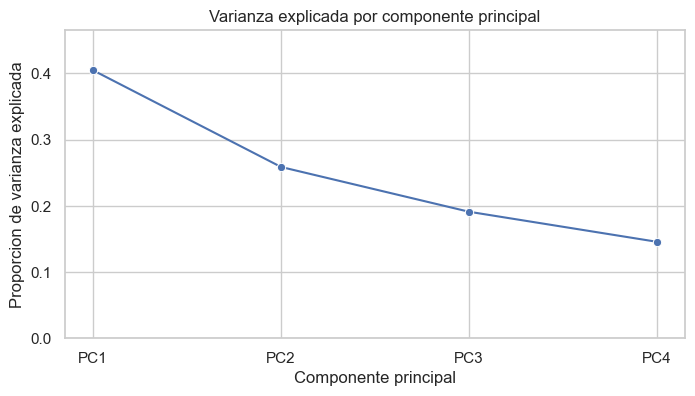

In [16]:
sns.set_theme(style='whitegrid')

# Scree plot:
# muestra cuanta informacion captura cada componente principal por separado.
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=varianza_explicada,
    x='componente',
    y='varianza_explicada',
    marker='o'
)
plt.title('Varianza explicada por componente principal')
plt.xlabel('Componente principal')
plt.ylabel('Proporcion de varianza explicada')
plt.ylim(0, varianza_explicada['varianza_explicada'].max() * 1.15)
guardar_grafica('01_scree_plot_tabla_final.png')
plt.show()


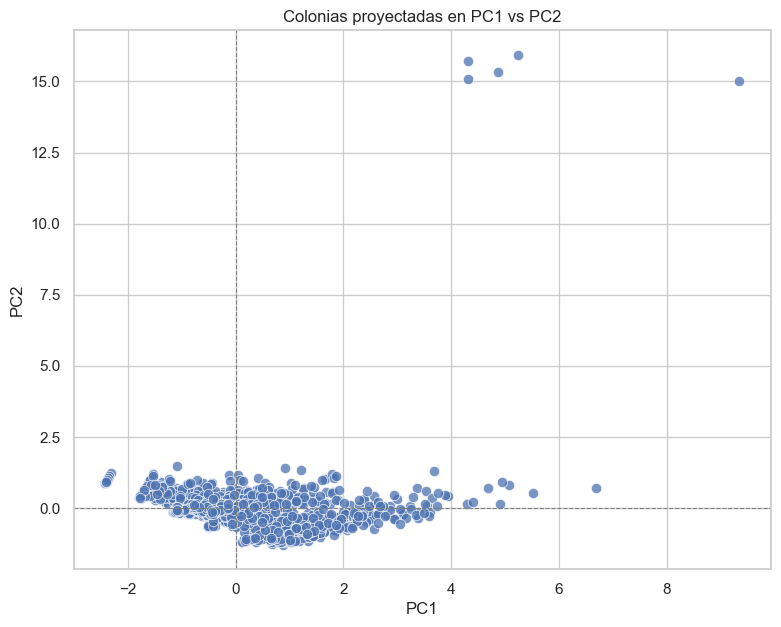

In [17]:
# Scatter PC1 vs PC2:
# cada punto es una colonia proyectada en los dos primeros componentes.
# cercania entre puntos sugiere perfiles parecidos segun las variables del PCA.
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=tabla_pca_resultado,
    x='PC1',
    y='PC2',
    s=55,
    alpha=0.75
)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Colonias proyectadas en PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
guardar_grafica('02_scatter_pc1_pc2_tabla_final.png')
plt.show()


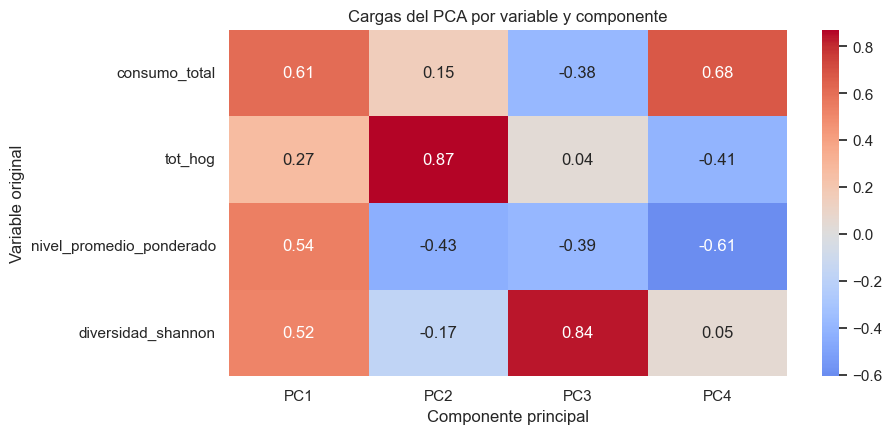

In [18]:
# Heatmap de cargas:
# resume como contribuye cada variable original a cada componente.
# valores grandes en magnitud indican mayor influencia en ese eje.
plt.figure(figsize=(9, 4.5))
sns.heatmap(cargas_pca, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Cargas del PCA por variable y componente')
plt.xlabel('Componente principal')
plt.ylabel('Variable original')
guardar_grafica('03_heatmap_cargas_tabla_final.png')
plt.show()


## 9. Revision de outliers

Antes de entrenar un modelo para predecir `consumo_total`, conviene revisar observaciones extremas en `tabla_pca_resultado`.

En esta seccion no eliminamos nada automaticamente. Primero generamos candidatos a revision para distinguir entre:
- colonias realmente extremas en consumo o perfil socioeconomico
- posibles errores o cruces anormalmente altos, sobre todo en `tot_hog`

La tabla base para esta revision es `tabla_pca_resultado`.


In [19]:
# Partimos de la tabla base con variables originales y componentes del PCA.
tabla_outliers = tabla_pca_resultado.copy()

# Variables originales que vamos a revisar con criterio IQR.
variables_revision = [
    'consumo_total',
    'tot_hog',
    'nivel_promedio_ponderado',
    'diversidad_shannon'
]

# Construimos una mascara de outliers por variable usando el rango intercuartil.
mascaras_iqr = {}
resumen_iqr = []

for col in variables_revision:
    serie = tabla_outliers[col].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (tabla_outliers[col] < limite_inferior) | (tabla_outliers[col] > limite_superior)
    mascaras_iqr[col] = mascara
    resumen_iqr.append({
        'variable': col,
        'q1': q1,
        'q3': q3,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'n_outliers': int(mascara.sum())
    })

resumen_iqr = pd.DataFrame(resumen_iqr)
resumen_iqr


,variable,q1,q3,limite_inferior,limite_superior,n_outliers
0,consumo_total,"6,681.33","92,310.85","-121,762.95","220,755.13",144
1,tot_hog,610.50,"2,471.00","-2,180.25","5,261.75",38
2,nivel_promedio_ponderado,1.41,2.42,-0.10,3.93,50
3,diversidad_shannon,0.03,0.73,-1.03,1.78,0


In [20]:
# Contamos cuantas veces aparece cada colonia como candidata a outlier.
# Algunas mascaras pueden traer NA si la variable original tiene faltantes.
# Por eso primero reemplazamos esos casos por False antes de convertir a entero.
mascaras_iqr_limpias = {
    col: mascara.fillna(False)
    for col, mascara in mascaras_iqr.items()
}

tabla_outliers['n_flags_iqr'] = sum(
    mascara.astype(int)
    for mascara in mascaras_iqr_limpias.values()
)

# Guardamos en una lista las variables por las que cada colonia fue marcada.
tabla_outliers['variables_flag'] = tabla_outliers.index.map(
    lambda idx: ', '.join([
        col for col, mascara in mascaras_iqr_limpias.items() if mascara.loc[idx]
    ])
)

# Candidatos generales: colonias marcadas al menos una vez.
candidatos_outliers = (
    tabla_outliers.loc[tabla_outliers['n_flags_iqr'] > 0, [
        'colonia_alcaldia',
        'consumo_total',
        'tot_hog',
        'nivel_promedio_ponderado',
        'diversidad_shannon',
        'PC1', 'PC2', 'PC3', 'PC4',
        'n_flags_iqr',
        'variables_flag'
    ]]
    .sort_values(['n_flags_iqr', 'tot_hog', 'consumo_total'], ascending=[False, False, False])
    .reset_index(drop=True)
)

candidatos_outliers.head(20)


,colonia_alcaldia,consumo_total,tot_hog,nivel_promedio_ponderado,diversidad_shannon,PC1,PC2,PC3,PC4,n_flags_iqr,variables_flag
0,CENTRO VIII | CUAUHTEMOC,"658,407.76",103831,2.78,1.27,9.35,15.03,-0.03,-3.88,2,"consumo_total, tot_hog"
1,LOMA DE LA PALMA | GUSTAVO A. MADERO,"366,962.56",103630,1.06,0.23,5.24,15.94,-0.51,-4.59,2,"consumo_total, tot_hog"
2,SANTA MARTHA ACATITLA_(PBLO) | IZTAPALAPA,"240,821.26",102844,1.02,0.09,4.31,15.73,-0.35,-5.30,2,"consumo_total, tot_hog"
3,NAPOLES | BENITO JUAREZ,"703,459.91",7501,3.35,0.87,5.08,0.82,-1.94,2.60,2,"consumo_total, tot_hog"
4,SAN JERONIMO ACULCO - LIDICE (PBLO) | LA MAGDA...,"715,020.88",7379,3.29,0.75,4.94,0.90,-2.22,2.71,2,"consumo_total, tot_hog"
5,GRANADA (AMPL) | MIGUEL HIDALGO,"297,960.34",7007,2.36,1.05,2.43,0.61,0.31,0.85,2,"consumo_total, tot_hog"
6,ANAHUAC I | MIGUEL HIDALGO,"450,851.13",6765,2.49,1.06,3.36,0.72,-0.26,1.73,2,"consumo_total, tot_hog"
7,ESCANDON II | MIGUEL HIDALGO,"431,574.28",6583,3.13,1.05,3.64,0.34,-0.51,1.16,2,"consumo_total, tot_hog"
8,PANTITLAN V | IZTACALCO,"396,850.59",6457,1.85,0.43,1.79,1.20,-1.16,1.79,2,"consumo_total, tot_hog"
9,ANAHUAC II | MIGUEL HIDALGO,"441,713.90",6412,2.42,1.27,3.53,0.59,0.25,1.77,2,"consumo_total, tot_hog"


In [21]:
# Revision rapida de outliers especialmente notorios.
# Aqui usamos reglas mas duras para detectar casos que vale la pena revisar primero.
outliers_notables = (
    tabla_outliers.loc[
        (tabla_outliers['tot_hog'] > 20000)
        | (tabla_outliers['consumo_total'] > 600000)
        | (tabla_outliers['n_flags_iqr'] >= 2),
        [
            'colonia_alcaldia',
            'consumo_total',
            'tot_hog',
            'nivel_promedio_ponderado',
            'diversidad_shannon',
            'PC1', 'PC2', 'PC3', 'PC4',
            'n_flags_iqr',
            'variables_flag'
        ]
    ]
    .sort_values(['tot_hog', 'consumo_total'], ascending=[False, False])
    .reset_index(drop=True)
)

outliers_notables


,colonia_alcaldia,consumo_total,tot_hog,nivel_promedio_ponderado,diversidad_shannon,PC1,PC2,PC3,PC4,n_flags_iqr,variables_flag
0,LOMAS DE SAN LORENZO II | IZTAPALAPA,"134,472.20",104459,1.46,0.69,4.88,15.33,1.13,-6.31,1,tot_hog
1,CENTRO VIII | CUAUHTEMOC,"658,407.76",103831,2.78,1.27,9.35,15.03,-0.03,-3.88,2,"consumo_total, tot_hog"
2,LOMA DE LA PALMA | GUSTAVO A. MADERO,"366,962.56",103630,1.06,0.23,5.24,15.94,-0.51,-4.59,2,"consumo_total, tot_hog"
3,SANTA MARTHA ACATITLA_(PBLO) | IZTAPALAPA,"240,821.26",102844,1.02,0.09,4.31,15.73,-0.35,-5.30,2,"consumo_total, tot_hog"
4,SAN MATEO XALPA (PBLO) | XOCHIMILCO,"77,883.30",102654,1.28,0.65,4.31,15.10,1.32,-6.41,1,tot_hog
5,NAPOLES | BENITO JUAREZ,"703,459.91",7501,3.35,0.87,5.08,0.82,-1.94,2.60,2,"consumo_total, tot_hog"
6,SAN JERONIMO ACULCO - LIDICE (PBLO) | LA MAGDA...,"715,020.88",7379,3.29,0.75,4.94,0.90,-2.22,2.71,2,"consumo_total, tot_hog"
7,GRANADA (AMPL) | MIGUEL HIDALGO,"297,960.34",7007,2.36,1.05,2.43,0.61,0.31,0.85,2,"consumo_total, tot_hog"
8,ANAHUAC I | MIGUEL HIDALGO,"450,851.13",6765,2.49,1.06,3.36,0.72,-0.26,1.73,2,"consumo_total, tot_hog"
9,ESCANDON II | MIGUEL HIDALGO,"431,574.28",6583,3.13,1.05,3.64,0.34,-0.51,1.16,2,"consumo_total, tot_hog"


In [22]:
# Construimos una tabla limpia eliminando las colonias detectadas en `outliers_notables`.
# Tomamos los identificadores de esa tabla y excluimos esas filas de la base principal.
colonias_outliers = outliers_notables['colonia_alcaldia'].dropna().unique().tolist()

tabla_limpia = (
    tabla_pca_resultado.loc[
        ~tabla_pca_resultado['colonia_alcaldia'].isin(colonias_outliers)
    ]
    .copy()
    .reset_index(drop=True)
)

print('Filas originales:', len(tabla_pca_resultado))
print('Filas eliminadas:', len(colonias_outliers))
print('Filas en tabla_limpia:', len(tabla_limpia))

tabla_limpia.head()


Filas originales: 1553
Filas eliminadas: 41
Filas en tabla_limpia: 1512


,colonia_alcaldia,consumo_total,tot_hog,nivel_promedio_ponderado,diversidad_shannon,PC1,PC2,PC3,PC4
0,10 DE ABRIL | MIGUEL HIDALGO,"17,694.87",108,3.73,0.63,0.88,-1.29,-0.29,-1.43
1,10 DE MAYO | VENUSTIANO CARRANZA,"46,761.97",547,1.90,0.33,-0.50,-0.13,-0.20,-0.02
2,12 DE DICIEMBRE | IZTAPALAPA,"18,441.64",815,1.68,0.63,-0.39,-0.15,0.64,-0.02
3,15 DE AGOSTO | GUSTAVO A. MADERO,"43,261.61",1079,2.23,0.54,0.00,-0.32,0.12,-0.29
4,16 DE SEPTIEMBRE | MIGUEL HIDALGO,"51,640.00",691,2.73,0.80,0.68,-0.73,0.41,-0.53


## 10. PCA sobre la tabla limpia

En esta seccion repetimos el PCA, pero ahora usando `tabla_limpia`, es decir, la tabla sin las colonias detectadas como outliers notorios.

La idea es volver a resumir la variacion conjunta de estas variables en nuevos ejes (`PC1`, `PC2`, etc.) y comparar si la estructura cambia al quitar observaciones extremas.

Variables que entran al PCA:
- `consumo_total`
- `tot_hog`
- `nivel_promedio_ponderado`
- `diversidad_shannon`

Antes de correr PCA, volvemos a estandarizar las variables porque cada una vive en una escala distinta.


In [23]:
# Repetimos el PCA usando ahora la tabla ya depurada de outliers notorios.
variables_pca_limpia = [
    'consumo_total',
    'tot_hog',
    'nivel_promedio_ponderado',
    'diversidad_shannon'
]

# Quitamos temporalmente filas con valores faltantes en las variables del PCA.
tabla_limpia_modelo = tabla_limpia.dropna(subset=variables_pca_limpia).copy()

X_limpia = tabla_limpia_modelo[variables_pca_limpia].copy()

# Estandarizacion (z-score) para hacer comparables las cuatro variables.
scaler_limpia = StandardScaler()
X_limpia_scaled = scaler_limpia.fit_transform(X_limpia)

# Ajustamos PCA con tantas componentes como variables originales.
pca_limpia = PCA(n_components=len(variables_pca_limpia), random_state=42)
X_limpia_pca = pca_limpia.fit_transform(X_limpia_scaled)

# Construimos una tabla con los scores del PCA sobre la tabla limpia.
component_names_limpia = [f'PC{i + 1}' for i in range(X_limpia_pca.shape[1])]
tabla_limpia_scores = pd.DataFrame(
    X_limpia_pca,
    columns=component_names_limpia,
    index=tabla_limpia_modelo.index
)
tabla_limpia_scores = pd.concat([
    tabla_limpia_modelo[['colonia_alcaldia']].reset_index(drop=True),
    tabla_limpia_scores.reset_index(drop=True)
], axis=1)

tabla_limpia_scores.head()


/Users/isalgadog/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/isalgadog/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/isalgadog/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


,colonia_alcaldia,PC1,PC2,PC3,PC4
0,10 DE ABRIL | MIGUEL HIDALGO,0.08,2.44,0.13,0.49
1,10 DE MAYO | VENUSTIANO CARRANZA,-0.78,0.42,-0.16,-0.34
2,12 DE DICIEMBRE | IZTAPALAPA,-0.58,0.23,0.70,-0.30
3,15 DE AGOSTO | GUSTAVO A. MADERO,-0.16,0.54,0.20,0.00
4,16 DE SEPTIEMBRE | MIGUEL HIDALGO,0.31,1.26,0.54,-0.12


### Como interpretar la varianza explicada en la tabla limpia

La interpretacion es la misma que antes, pero ahora sobre el conjunto sin outliers notorios.

- `varianza_explicada` indica que proporcion de la variacion total captura cada componente por separado
- `varianza_acumulada` indica cuanta informacion se resume al sumar componentes en orden

La comparacion con la version anterior permite ver si los outliers estaban empujando demasiado la estructura del PCA.


In [24]:
# Varianza explicada del PCA sobre la tabla limpia.
varianza_explicada_limpia = pd.DataFrame({
    'componente': component_names_limpia,
    'varianza_explicada': pca_limpia.explained_variance_ratio_,
    'varianza_acumulada': np.cumsum(pca_limpia.explained_variance_ratio_)
})

varianza_explicada_limpia


,componente,varianza_explicada,varianza_acumulada
0,PC1,0.46,0.46
1,PC2,0.26,0.71
2,PC3,0.18,0.89
3,PC4,0.11,1.00


In [25]:
# Cargas del PCA sobre la tabla limpia.
cargas_pca_limpia = pd.DataFrame(
    pca_limpia.components_.T,
    index=variables_pca_limpia,
    columns=component_names_limpia
)

cargas_pca_limpia


,PC1,PC2,PC3,PC4
consumo_total,0.59,-0.10,-0.53,-0.61
tot_hog,0.49,-0.63,-0.04,0.61
nivel_promedio_ponderado,0.38,0.76,-0.24,0.46
diversidad_shannon,0.52,0.14,0.81,-0.22


In [26]:
# Unimos la tabla limpia con sus nuevos componentes principales.
# Primero quitamos los PC del PCA anterior para evitar columnas duplicadas
# como `PC1_x` y `PC1_y` despues del merge.
columnas_pc_previas = [col for col in tabla_limpia.columns if col.startswith('PC')]
tabla_limpia_base = tabla_limpia.drop(columns=columnas_pc_previas, errors='ignore').copy()

tabla_limpia_resultado = tabla_limpia_base.merge(
    tabla_limpia_scores,
    on='colonia_alcaldia',
    how='left'
)

tabla_limpia_resultado.head()

# Guardamos la tabla limpia con componentes principales en CSV.
salida_tabla_limpia = Path('consumo_agua/tabla_limpia_resultado.csv')
tabla_limpia_resultado.to_csv(salida_tabla_limpia, index=False)
print(f'Tabla guardada en: {salida_tabla_limpia.resolve()}')


Tabla guardada en: /Users/isalgadog/Documents/Code/agua_cdmx/consumo_agua/tabla_limpia_resultado.csv


## 11. Visualizaciones del PCA sobre la tabla limpia

En esta seccion repetimos las mismas tres visualizaciones, pero ahora usando el PCA calculado sobre `tabla_limpia`.


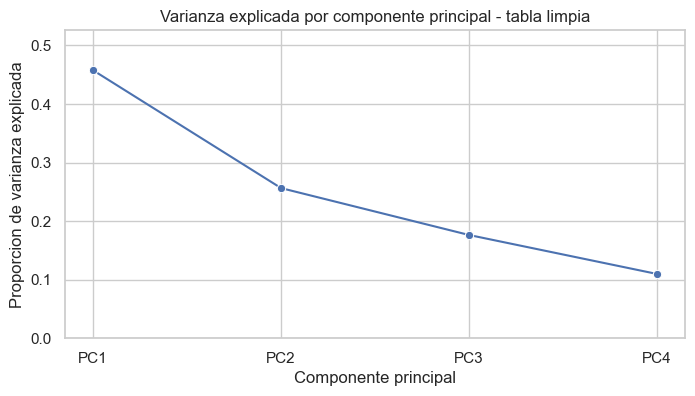

In [27]:
# Scree plot del PCA sobre la tabla limpia.
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=varianza_explicada_limpia,
    x='componente',
    y='varianza_explicada',
    marker='o'
)
plt.title('Varianza explicada por componente principal - tabla limpia')
plt.xlabel('Componente principal')
plt.ylabel('Proporcion de varianza explicada')
plt.ylim(0, varianza_explicada_limpia['varianza_explicada'].max() * 1.15)
guardar_grafica('04_scree_plot_tabla_limpia.png')
plt.show()


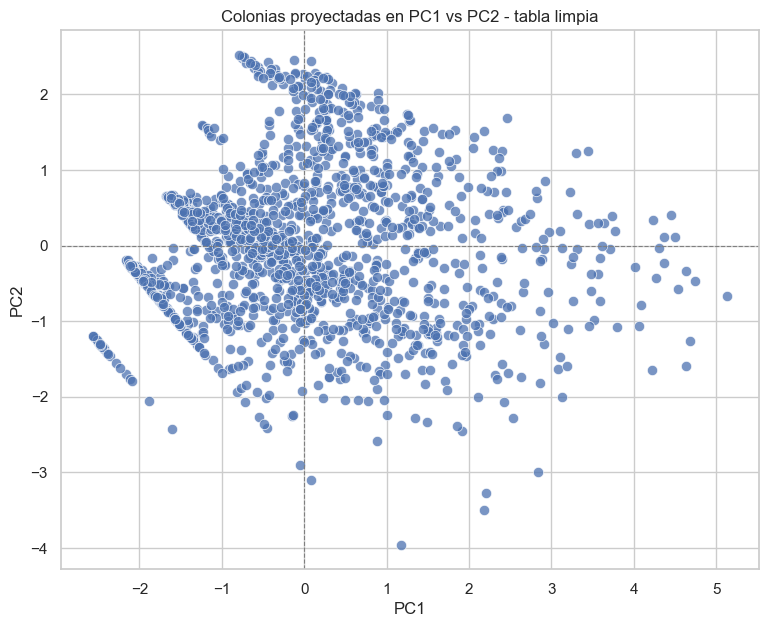

In [28]:
# Scatter PC1 vs PC2 sobre la tabla limpia.
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=tabla_limpia_resultado,
    x='PC1',
    y='PC2',
    s=55,
    alpha=0.75
)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Colonias proyectadas en PC1 vs PC2 - tabla limpia')
plt.xlabel('PC1')
plt.ylabel('PC2')
guardar_grafica('05_scatter_pc1_pc2_tabla_limpia.png')
plt.show()


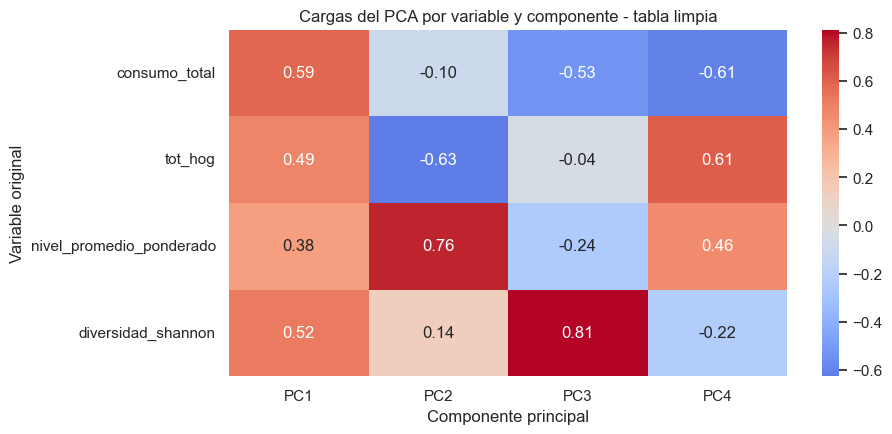

In [29]:
# Heatmap de cargas del PCA sobre la tabla limpia.
plt.figure(figsize=(9, 4.5))
sns.heatmap(cargas_pca_limpia, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Cargas del PCA por variable y componente - tabla limpia')
plt.xlabel('Componente principal')
plt.ylabel('Variable original')
guardar_grafica('06_heatmap_cargas_tabla_limpia.png')
plt.show()


## 12. Prediccion de `consumo_total`

En esta seccion construimos un modelo base para predecir `consumo_total` a partir de las otras variables disponibles en `tabla_limpia`.

Variables predictoras:
- `tot_hog`
- `nivel_promedio_ponderado`
- `diversidad_shannon`

Variable objetivo:
- `consumo_total`

Empezamos con una regresion lineal porque es un modelo interpretable y sirve como linea base.

Nota importante: para prediccion no usamos un PCA que incluya `consumo_total`, porque eso meteria informacion de la variable objetivo dentro de las entradas del modelo.


In [30]:
# Preparamos la tabla para modelado supervisado usando la tabla limpia.
variables_predictoras = [
    'tot_hog',
    'nivel_promedio_ponderado',
    'diversidad_shannon'
]
variable_objetivo = 'consumo_total'

tabla_modelo = tabla_limpia.dropna(subset=variables_predictoras + [variable_objetivo]).copy()

X = tabla_modelo[variables_predictoras]
y = tabla_modelo[variable_objetivo]

print('Filas para modelado:', len(tabla_modelo))
print('Numero de variables predictoras:', X.shape[1])

tabla_modelo.head()


Filas para modelado: 1510
Numero de variables predictoras: 3


,colonia_alcaldia,consumo_total,tot_hog,nivel_promedio_ponderado,diversidad_shannon,PC1,PC2,PC3,PC4
0,10 DE ABRIL | MIGUEL HIDALGO,"17,694.87",108,3.73,0.63,0.88,-1.29,-0.29,-1.43
1,10 DE MAYO | VENUSTIANO CARRANZA,"46,761.97",547,1.90,0.33,-0.50,-0.13,-0.20,-0.02
2,12 DE DICIEMBRE | IZTAPALAPA,"18,441.64",815,1.68,0.63,-0.39,-0.15,0.64,-0.02
3,15 DE AGOSTO | GUSTAVO A. MADERO,"43,261.61",1079,2.23,0.54,0.00,-0.32,0.12,-0.29
4,16 DE SEPTIEMBRE | MIGUEL HIDALGO,"51,640.00",691,2.73,0.80,0.68,-0.73,0.41,-0.53


In [31]:
# Separamos entrenamiento y prueba para evaluar el modelo fuera de muestra.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Ajustamos una regresion lineal como modelo base.
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train, y_train)

# Predicciones sobre el conjunto de prueba.
y_pred = modelo_regresion.predict(X_test)

# Resumen de metricas de desempeno.
rmse = mean_squared_error(y_test, y_pred) ** 0.5
metricas_modelo = pd.DataFrame({
    'metrica': ['R2', 'MAE', 'RMSE'],
    'valor': [
        r2_score(y_test, y_pred),
        mean_absolute_error(y_test, y_pred),
        rmse
    ]
})

metricas_modelo


,metrica,valor
0,R2,0.31
1,MAE,"51,677.86"
2,RMSE,"74,572.61"


In [32]:
# Coeficientes del modelo para interpretar el aporte de cada variable.
coeficientes_modelo = pd.DataFrame({
    'variable': variables_predictoras,
    'coeficiente': modelo_regresion.coef_
}).sort_values('coeficiente', ascending=False).reset_index(drop=True)

intercepto_modelo = modelo_regresion.intercept_

print('Intercepto:', intercepto_modelo)
coeficientes_modelo


Intercepto: -46434.72851089967


,variable,coeficiente
0,nivel_promedio_ponderado,"28,386.82"
1,diversidad_shannon,"18,505.92"
2,tot_hog,27.80


In [33]:
# Comparamos valores reales y predichos para una muestra del conjunto de prueba.
comparacion_predicciones = pd.DataFrame({
    'consumo_real': y_test.values,
    'consumo_predicho': y_pred,
    'error': y_test.values - y_pred
}).reset_index(drop=True)

comparacion_predicciones.head(10)


,consumo_real,consumo_predicho,error
0,"236,860.46","105,320.31","131,540.15"
1,580.27,"40,976.61","-40,396.34"
2,153.30,"34,721.63","-34,568.33"
3,"82,294.92","83,864.41","-1,569.49"
4,"77,963.71","151,261.29","-73,297.58"
5,"18,189.16","73,531.19","-55,342.03"
6,"169,058.70","109,454.84","59,603.86"
7,"6,256.99","25,713.65","-19,456.66"
8,"70,917.61","205,954.12","-135,036.51"
9,"84,821.31","63,962.65","20,858.66"


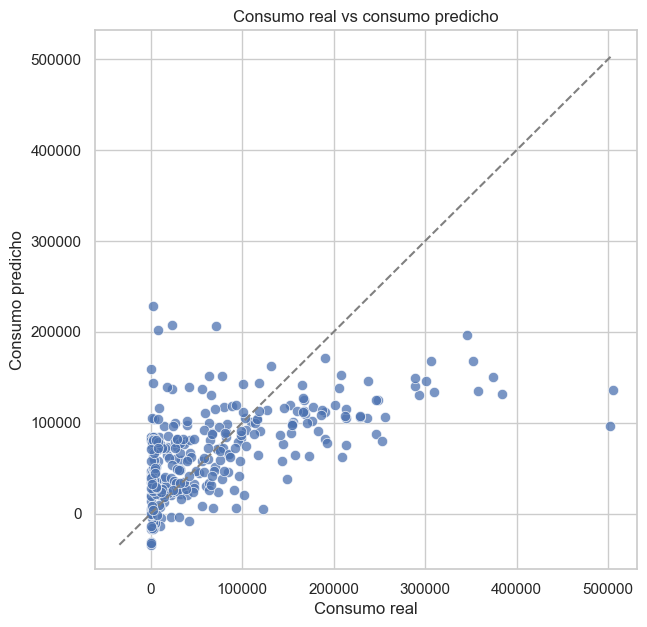

In [34]:
# Grafica de valores reales contra predichos.
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=y_test,
    y=y_pred,
    s=55,
    alpha=0.75
)

limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())
plt.plot([limite_min, limite_max], [limite_min, limite_max], linestyle='--', color='gray')
plt.title('Consumo real vs consumo predicho')
plt.xlabel('Consumo real')
plt.ylabel('Consumo predicho')
guardar_grafica('07_prediccion_regresion_lineal.png')
plt.show()


## 13. Prediccion con Random Forest

Como la regresion lineal puede quedarse corta si la relacion entre variables no es lineal, aqui probamos un `RandomForestRegressor` sobre la misma particion de entrenamiento y prueba.

La ventaja de este modelo es que puede capturar relaciones mas complejas e interacciones entre variables sin exigir una forma funcional lineal.


In [35]:
# Ajustamos un Random Forest sobre la misma division train/test.
modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

# Predicciones del Random Forest sobre el conjunto de prueba.
y_pred_rf = modelo_rf.predict(X_test)

# Metricas de desempeno del Random Forest.
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
metricas_modelo_rf = pd.DataFrame({
    'metrica': ['R2', 'MAE', 'RMSE'],
    'valor': [
        r2_score(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_rf),
        rmse_rf
    ]
})

metricas_modelo_rf


,metrica,valor
0,R2,0.32
1,MAE,"46,786.76"
2,RMSE,"73,975.26"


In [36]:
# Importancia de variables segun el Random Forest.
importancia_variables_rf = pd.DataFrame({
    'variable': variables_predictoras,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False).reset_index(drop=True)

importancia_variables_rf


,variable,importancia
0,tot_hog,0.46
1,nivel_promedio_ponderado,0.35
2,diversidad_shannon,0.19


In [37]:
# Comparacion de valores reales y predichos con Random Forest.
comparacion_predicciones_rf = pd.DataFrame({
    'consumo_real': y_test.values,
    'consumo_predicho_rf': y_pred_rf,
    'error_rf': y_test.values - y_pred_rf
}).reset_index(drop=True)

comparacion_predicciones_rf.head(10)


,consumo_real,consumo_predicho_rf,error_rf
0,"236,860.46","178,663.70","58,196.76"
1,580.27,"52,344.64","-51,764.37"
2,153.30,"49,485.81","-49,332.51"
3,"82,294.92","57,979.95","24,314.97"
4,"77,963.71","173,455.83","-95,492.12"
5,"18,189.16","63,209.18","-45,020.02"
6,"169,058.70","47,595.03","121,463.67"
7,"6,256.99","23,087.14","-16,830.15"
8,"70,917.61","45,166.79","25,750.82"
9,"84,821.31","45,021.50","39,799.81"


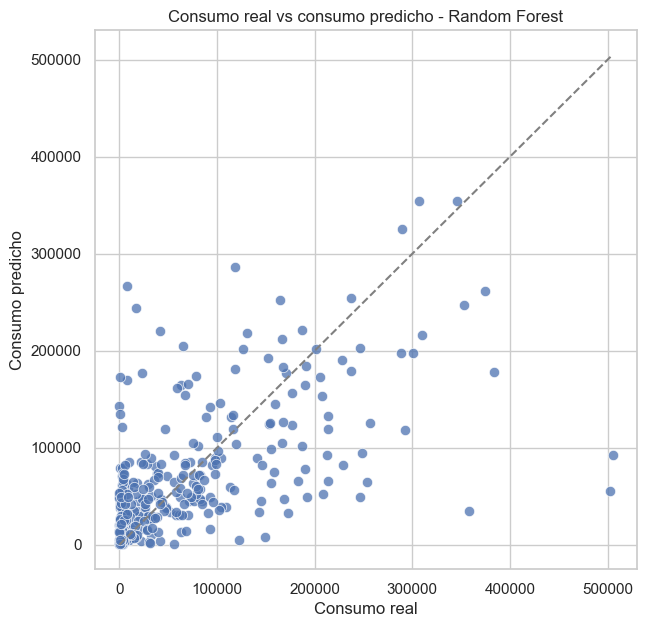

In [38]:
# Grafica de valores reales contra predichos con Random Forest.
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    s=55,
    alpha=0.75
)

limite_min_rf = min(y_test.min(), y_pred_rf.min())
limite_max_rf = max(y_test.max(), y_pred_rf.max())
plt.plot([limite_min_rf, limite_max_rf], [limite_min_rf, limite_max_rf], linestyle='--', color='gray')
plt.title('Consumo real vs consumo predicho - Random Forest')
plt.xlabel('Consumo real')
plt.ylabel('Consumo predicho')
guardar_grafica('08_prediccion_random_forest.png')
plt.show()


In [39]:
# Tabla comparativa entre regresion lineal y Random Forest.
comparacion_metricas_modelos = metricas_modelo.merge(
    metricas_modelo_rf,
    on='metrica',
    suffixes=('_regresion', '_random_forest')
)

comparacion_metricas_modelos


,metrica,valor_regresion,valor_random_forest
0,R2,0.31,0.32
1,MAE,"51,677.86","46,786.76"
2,RMSE,"74,572.61","73,975.26"


## 14. Prediccion con KNeighborsRegressor

Como `KNeighborsRegressor` depende de distancias entre observaciones, aqui conviene estandarizar las variables predictoras antes de entrenar.

La idea es predecir el consumo de una colonia a partir del comportamiento de sus colonias mas parecidas en el espacio de variables.


In [40]:
# Estandarizamos las variables para KNN usando solo el conjunto de entrenamiento.
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train)
X_test_knn = scaler_knn.transform(X_test)

# Ajustamos un modelo KNN sobre la misma division train/test.
modelo_knn = KNeighborsRegressor(
    n_neighbors=29,
    weights='distance',
    metric='minkowski',
    p=2
)

modelo_knn.fit(X_train_knn, y_train)

# Predicciones del modelo KNN sobre el conjunto de prueba.
y_pred_knn = modelo_knn.predict(X_test_knn)

# Metricas de desempeno del modelo KNN.
rmse_knn = mean_squared_error(y_test, y_pred_knn) ** 0.5
metricas_modelo_knn = pd.DataFrame({
    'metrica': ['R2', 'MAE', 'RMSE'],
    'valor': [
        r2_score(y_test, y_pred_knn),
        mean_absolute_error(y_test, y_pred_knn),
        rmse_knn
    ]
})

metricas_modelo_knn


,metrica,valor
0,R2,0.37
1,MAE,"46,374.53"
2,RMSE,"71,208.84"


In [41]:
# Comparacion de valores reales y predichos con KNN.
comparacion_predicciones_knn = pd.DataFrame({
    'consumo_real': y_test.values,
    'consumo_predicho_knn': y_pred_knn,
    'error_knn': y_test.values - y_pred_knn
}).reset_index(drop=True)

comparacion_predicciones_knn.head(10)


,consumo_real,consumo_predicho_knn,error_knn
0,"236,860.46","144,395.99","92,464.47"
1,580.27,"37,598.07","-37,017.80"
2,153.30,"38,592.36","-38,439.06"
3,"82,294.92","58,501.44","23,793.48"
4,"77,963.71","155,892.03","-77,928.32"
5,"18,189.16","58,618.28","-40,429.12"
6,"169,058.70","60,928.54","108,130.16"
7,"6,256.99","21,466.25","-15,209.26"
8,"70,917.61","90,468.32","-19,550.71"
9,"84,821.31","55,124.79","29,696.52"


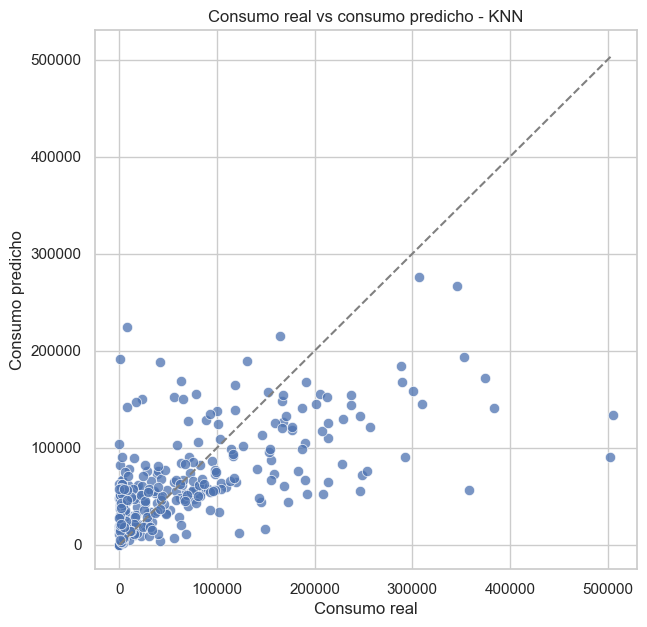

In [42]:
# Grafica de valores reales contra predichos con KNN.
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=y_test,
    y=y_pred_knn,
    s=55,
    alpha=0.75
)

limite_min_knn = min(y_test.min(), y_pred_knn.min())
limite_max_knn = max(y_test.max(), y_pred_knn.max())
plt.plot([limite_min_knn, limite_max_knn], [limite_min_knn, limite_max_knn], linestyle='--', color='gray')
plt.title('Consumo real vs consumo predicho - KNN')
plt.xlabel('Consumo real')
plt.ylabel('Consumo predicho')
guardar_grafica('09_prediccion_knn.png')
plt.show()


In [43]:
# Tabla comparativa entre regresion lineal, Random Forest y KNN.
comparacion_metricas_modelos = metricas_modelo.merge(
    metricas_modelo_rf,
    on='metrica',
    suffixes=('_regresion', '_random_forest')
).merge(
    metricas_modelo_knn.rename(columns={'valor': 'valor_knn'}),
    on='metrica'
)

comparacion_metricas_modelos


,metrica,valor_regresion,valor_random_forest,valor_knn
0,R2,0.31,0.32,0.37
1,MAE,"51,677.86","46,786.76","46,374.53"
2,RMSE,"74,572.61","73,975.26","71,208.84"
